# Implémenter un modèle de scoring

L’entreprise souhaite mettre en œuvre un outil de `scoring crédit` pour calculer la probabilité qu’un client rembourse son crédit, puis classifie le client en `Défaut(D - classe 1)` ou  `Non-Défaut (ND - Classe 0`). Elle souhaite donc développer un algorithme de classification en s’appuyant sur des sources de données variées (données comportementales, données provenant d'autres institutions financières, etc.).

L'objectif est donc d'utiliser ces données financières et socio-économiques historiques pour prédire si un client donné sera en mesure de rembourser le prêt accordé. Il s'agit d'une tâche de classification supervisée standard :

- **Supervisé** : les étiquettes sont incluses dans les données d'entraînement et l'objectif est d'entraîner un modèle pour apprendre à prédire les étiquettes à partir des caractéristiques
- **Classification** : La target est une variable binaire, 0 (credit accordé), 1 (credit refusé)

## 0. Problématique Business

Lorsqu'une instituation financière prête de l'argent à une personne, elle prend le risque que cette dernière `ne rembourse pas cet argent dans le délai convenu`. Ce risque est appelé **Risque de Crédit**. Alors avant d'octroyer du crédit, les instituation financière vérifient si la personne qui demandent un prêt sera capable ou pas de le rembourser (`solvabilité`). 

Grâce à des modèles de Machine Learning, les intitutions financières peuvent modéliser la **probabilité de défaut - `PD`**  de paiement  et ainsi attribuer un `score` à chaque nouveau demandeur de crédit : **Credit Scoring**. 

Dans ce projet, nous apprendrons à construire et évaluer un modèle de Machine Learning pour prédire si un demandeur de crédit sera en défaut de paiement ou non. Il s'agit d'un problème de **classification binaire**. 


En générale le défaut est observé en fonction du taux d'endette, plus celui-ci est élevé, plus le probabilité que le client ne rembpurse pas son credit soit élévé. 

Mais dans le cas espèce, l'évènement défaut est déclenché lorsque le client est difficulté de paiement c-à-d qu'il a un retard de paiementde plus de X jours sur au moins une des Y premières échéances.

## 1. Mise en Place de l'Environnement de Travail

#### Import des librairies utiles à l'analyse exploratoire

In [ ]:
# Importation des librairies Python nécessaires
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import sys, jinja2


# Utils 
import os
import gc
import time
import missingno as msno
from contextlib import contextmanager

# Librairie de preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Librairie de modélisation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
CONFIG_PATH = PROJECT_ROOT / 'notebooks' / 'notebook_params.yaml'

def data_path(relative_path: str) -> Path:
    return DATA_DIR / relative_path

SAMPLE_DATA = False
SAMPLE_FRACTION = 0.01

if CONFIG_PATH.exists():
    try:
        import yaml
    except ImportError as exc:
        raise ImportError('pyyaml is required to load notebook_params.yaml') from exc
    config = yaml.safe_load(CONFIG_PATH.read_text()) or {}
    sample_cfg = config.get('exploration', {})
    SAMPLE_DATA = bool(sample_cfg.get('SAMPLE_DATA', SAMPLE_DATA))
    SAMPLE_FRACTION = float(sample_cfg.get('SAMPLE_FRACTION', SAMPLE_FRACTION))
else:
    print(f'Config not found: {CONFIG_PATH}. Using defaults.')

def maybe_sample_head(df, fraction=SAMPLE_FRACTION, enabled=SAMPLE_DATA):
    if not enabled:
        return df
    if not 0 < fraction <= 1:
        raise ValueError('SAMPLE_FRACTION must be in (0, 1].')
    n_rows = max(1, int(len(df) * fraction))
    return df.head(n_rows).copy()

if SAMPLE_DATA:
    print(f'Sample mode enabled: using first {SAMPLE_FRACTION:.0%} of rows per dataset')

print('DATA_DIR:', DATA_DIR)


#### Format d'affichage des données

In [ ]:
# Affichage d'un maximum de les lignes et colonnes
pd.set_option('display.max_column', 200)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 200)

#pd.options.display.float_format = '{:, .2f}'.format

#chiffre après la virgule
pd.set_option('display.precision', 3)

# Affichage des erreurs
import warnings
warnings.filterwarnings("ignore")

## 2. Chargement et Presentation du Jeu de données

### 2.1  Descrition des Jeu de données

Il existe 7 fichiers de données différents :

- **application_train/application_test** : les jeu de données de test et d'entrainement avec des informations sur chaque demande de prêt. Chaque prêt a sa propre ligne et est identifié par le `SK_ID_CURR`. Le jeu de données d'entrainement est accompagnées de la TARGET indiquant 0 : le prêt a été remboursé et 1 : le prêt n'a pas été remboursé.

- **bureau** : données concernant les crédits antérieurs du client auprès d'autres institutions financières. Chaque crédit précédent a sa propre ligne dans le bureau et est identifié par le `SK_ID_BUREAU`. Chaque prêt dans les données de l'application/demande peut avoir plusieurs crédits précédents.

- **bureau_balance** : les données mensuelles sur les crédits précédents dans le bureau. Chaque ligne correspond à un mois d'un crédit précédent, et un seul crédit précédent peut avoir plusieurs lignes, une pour chaque mois de la durée du crédit.

- **previous_application** : demandes de prêt précédentes auprès de l'intitution des clients qui ont des prêts dans le dataset **application**. Chaque prêt en cours dans application_data peut avoir plusieurs prêts précédents. Chaque previous_application a une ligne et est identifiée par la caractéristique `SK_ID_PREV`.

- **POS_CASH_BALANCE** : données mensuelles sur les points de vente précédents ou les prêts en espèces que les clients ont eus avec Home Credit. Chaque ligne correspond à un mois d'un point de vente ou d'un prêt en espèces précédent, et un seul prêt précédent peut avoir plusieurs lignes.

- **credit_card_balance** : données mensuelles sur les cartes de crédit précédentes que les clients ont eues avec l'institution financière. Chaque ligne correspond à un mois du solde d'une carte de crédit, et une seule carte de crédit peut avoir plusieurs lignes.

- **installments_payment** : historique de paiement pour les prêts précédents chez l'institution financière. Il y a une ligne pour chaque paiement effectué et une ligne pour chaque paiement manqué.




**Source Jeu de données** : https://www.kaggle.com/c/home-credit-default-risk/data

Kernel Kaggle Utilisées : 
- HomeCreditRisk: Extensive EDA + Baseline -> https://www.kaggle.com/code/shivamb/homecreditrisk-extensive-eda-baseline-0-772

> Le diagramme ci-dessous (fourni par l'institutin financière) montre comment les tables sont liées. Cela sera pourrait être utile lorsque nous aurons besoin de définir des relations.

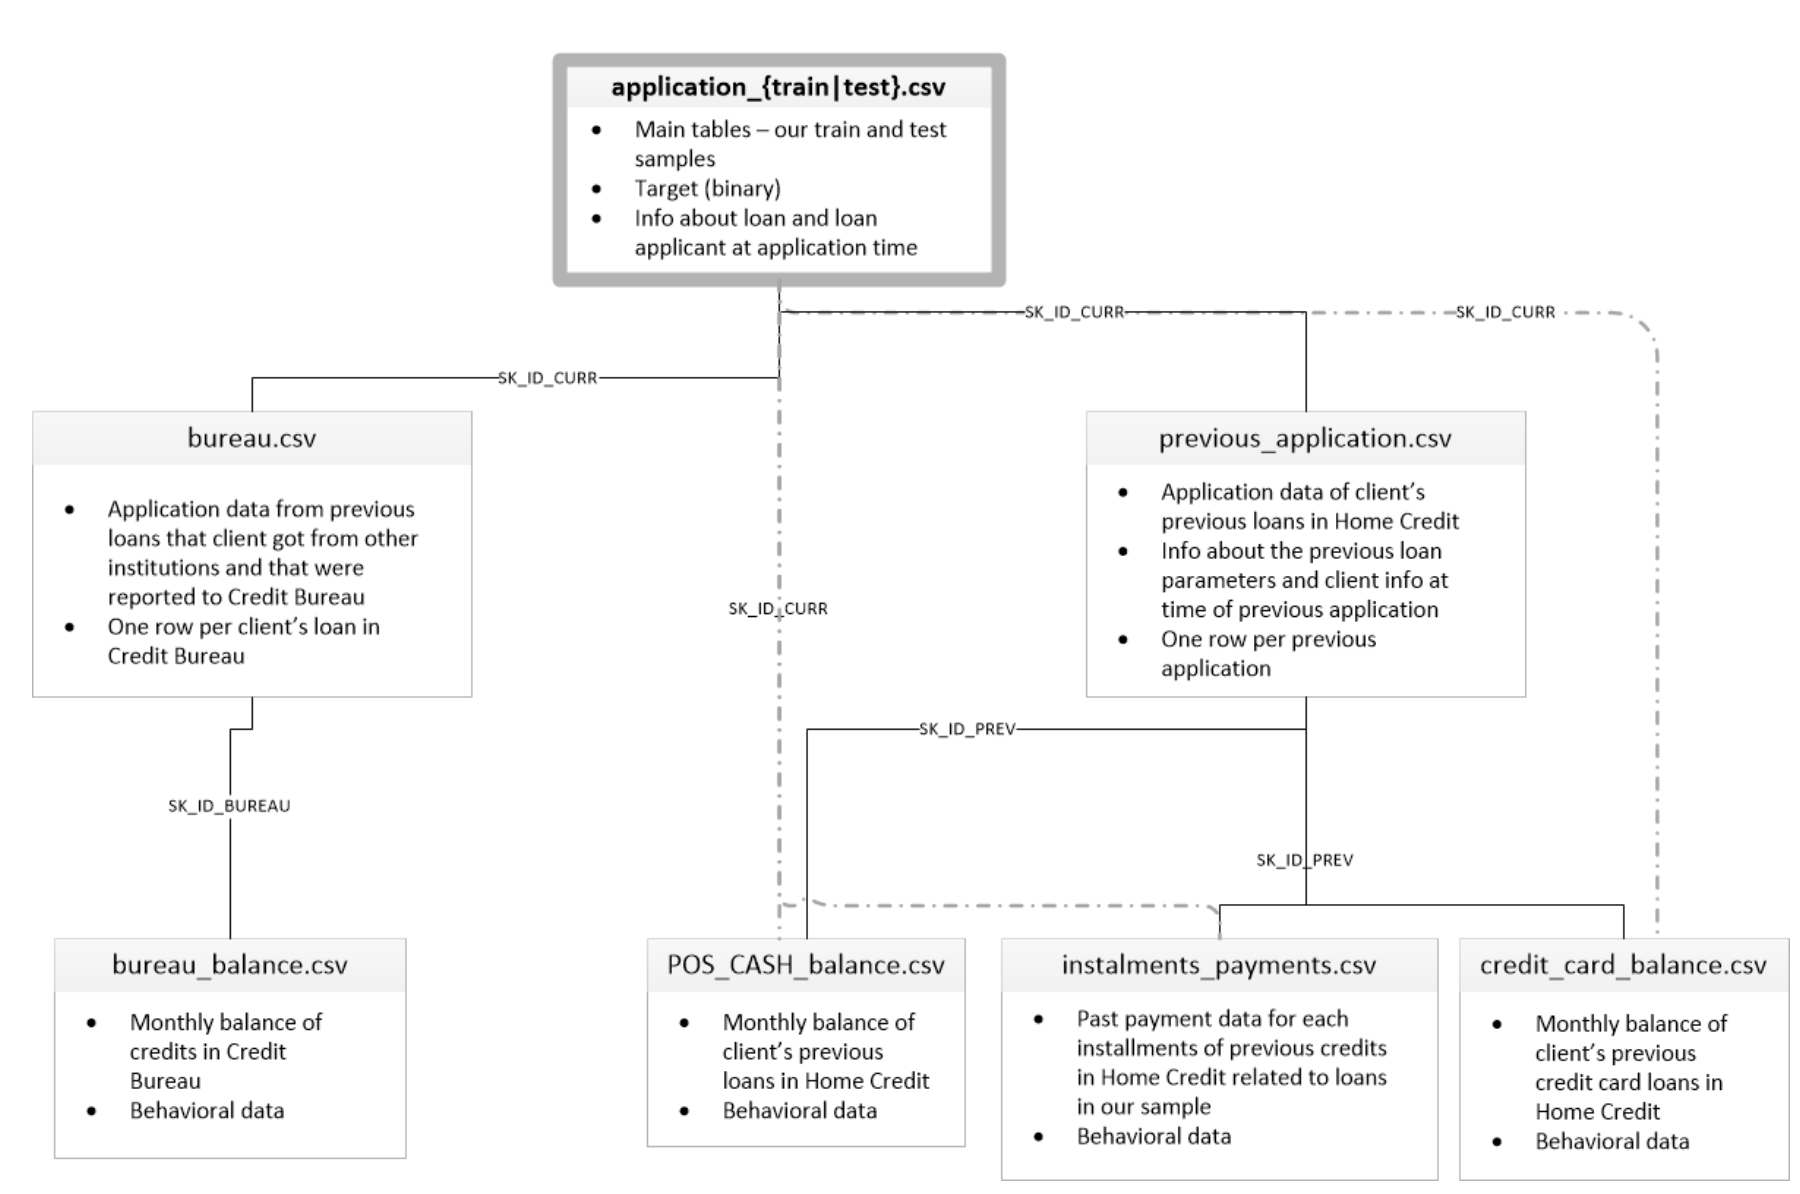

In [ ]:
from contextlib import contextmanager
import time

@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

In [ ]:
# Compression des données au format .parquet
def write_parquet_file():
    with timer("reading and writing application_train data to parquet"):
        application_train = pd.read_csv(data_path('application_train.csv'))
        application_train = maybe_sample_head(application_train)
        application_train.to_parquet(data_path('application_train.parquet'))
        del application_train
        gc.collect()
    
    with timer("reading and writing application_test data to parquet"):
        application_test = pd.read_csv(data_path('application_test.csv'))
        application_test = maybe_sample_head(application_test)
        application_test.to_parquet(data_path('application_test.parquet'))
        del application_test
        gc.collect()
    
    with timer("reading and writing previous_application data to parquet"):
        previous_application = pd.read_csv(data_path('previous_application.csv'))
        previous_application = maybe_sample_head(previous_application)
        previous_application.to_parquet(data_path('previous_application.parquet'))
        del previous_application
        gc.collect()
    
    with timer("reading and writing bureau data to parquet"):
        bureau = pd.read_csv(data_path('bureau.csv'))
        bureau = maybe_sample_head(bureau)
        bureau.to_parquet(data_path('bureau.parquet'))
        del bureau
        gc.collect()
        
    with timer("reading and writing bureau_balance data to parquet"):
        bureau_balance = pd.read_csv(data_path('bureau_balance.csv'))
        bureau_balance = maybe_sample_head(bureau_balance)
        bureau_balance.to_parquet(data_path('bureau_balance.parquet'))
        del bureau_balance
        gc.collect()
    
    with timer("reading and writing POS_CASH_balance data to parquet"):
        POS_CASH_balance = pd.read_csv(data_path('POS_CASH_balance.csv'))
        POS_CASH_balance = maybe_sample_head(POS_CASH_balance)
        POS_CASH_balance.to_parquet(data_path('POS_CASH_balance.parquet'))
        del POS_CASH_balance
        gc.collect()
    
    with timer("reading and writing installments_payments data to parquet"):
        installments_payments = pd.read_csv(data_path('installments_payments.csv'))
        installments_payments = maybe_sample_head(installments_payments)
        installments_payments.to_parquet(data_path('installments_payments.parquet'))
        del installments_payments
        gc.collect()
    
    with timer("reading and writing credit_card_balance data to parquet"):
        credit_card_balance = pd.read_csv(data_path('credit_card_balance.csv'))
        credit_card_balance = maybe_sample_head(credit_card_balance)
        credit_card_balance.to_parquet(data_path('credit_card_balance.parquet'))
        del credit_card_balance
        gc.collect()


## 2.2 Importation des jeux de donnnées

In [ ]:
# Read and write all datasets into parquet format
write_parquet_file()

In [ ]:
# List files available
print(os.listdir(DATA_DIR))

In [ ]:
def read_datasets():   
    with timer("Datasets loaded"):
        print("Loading data ... ")
        app_train = maybe_sample_head(pd.read_parquet(data_path('application_train.parquet')))
        print("\tapplication_train cols_num: {}, obervations: {}".format(len(app_train.columns),
                                                                         app_train.shape[0]))
        app_test = maybe_sample_head(pd.read_parquet(data_path('application_test.parquet')))
        print("\tapplication_test cols_num: {}, obervations: {}".format(len(app_test.columns), 
                                                                        app_test.shape[0]))
        prev_app = maybe_sample_head(pd.read_parquet(data_path('previous_application.parquet')))
        print("\tprevious_application cols_num: {}, obervations: {}".format(len(prev_app.columns), 
                                                                            prev_app.shape[0]))
        bureau = maybe_sample_head(pd.read_parquet(data_path('bureau.parquet')))
        print("\tbureau cols_num: {}, obervations: {}".format(len(bureau.columns), 
                                                              bureau.shape[0]))
        bur_bal = maybe_sample_head(pd.read_parquet(data_path('bureau_balance.parquet')))
        print("\tbureau_balance cols_num: {}, obervations: {}".format(len(bur_bal.columns),
                                                                      bur_bal.shape[0]))
        pos_cash_bal = maybe_sample_head(pd.read_parquet(data_path('POS_CASH_balance.parquet')))
        print("\tPOS_CASH_balance cols_num: {}, obervations: {}".format(len(pos_cash_bal.columns), 
                                                                        pos_cash_bal.shape[0]))
        inst_pay = maybe_sample_head(pd.read_parquet(data_path('installments_payments.parquet')))
        print("\tinstallments_payments cols_num: {}, obervations: {}".format(len(inst_pay.columns), 
                                                                             inst_pay.shape[0]))
        cred_card_bal = maybe_sample_head(pd.read_parquet(data_path('credit_card_balance.parquet')))
        print("\tcredit_card_balance cols_num: {}, obervations: {}".format(len(cred_card_bal.columns), 
                                                                           cred_card_bal.shape[0]))

        return app_train, app_test, prev_app, bureau, bur_bal, pos_cash_bal, inst_pay, cred_card_bal


In [ ]:
# Reading all files
app_train, app_test, prev_app, bureau, bur_bal, pos_cash_bal, inst_pay, cred_card_bal= read_datasets()

In [ ]:
app_train.head()

In [ ]:
sample_submission = pd.read_csv(data_path('sample_submission.csv'), delimiter=',',header='infer')
sample_submission.head()

In [ ]:
columns_description = pd.read_csv(data_path('HomeCredit_columns_description.csv'), encoding='cp1252')
columns_description.drop(columns="Unnamed: 0", inplace=True)
#columns_description.head()

### 2.3 Analyse de forme la forme du Jeu de données

In [ ]:
# Collections for each dataset
datasets = [app_train, app_test, prev_app, bureau, bur_bal, pos_cash_bal, inst_pay, cred_card_bal, 
            sample_submission]

names = ['application_train', 'application_test','previous_application', 'bureau', 'bureau_balance',
         'POS_CASH_balance', 'installments_payments', 'credit_card_balance', 'sample_submission']


# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) 
                                 for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) 
                             for df in datasets]

In [ ]:
data_info.style.background_gradient()

### 2.4 Jointure des datasets en un seul jeu de données

In [ ]:
# Jointure application train et test 

def app_train_test():
    # Read data and merge
    application_train = maybe_sample_head(pd.read_parquet(data_path('application_train.parquet')))
    application_test = maybe_sample_head(pd.read_parquet(data_path('application_test.parquet')))

    application_test['is_test'] = 1
    application_test['is_train'] = 0
    application_train['is_test'] = 0
    application_train['is_train'] = 1

    # target variable
    train_y = application_train['TARGET']

    # Train and test datas
    train_X = application_train.drop(['TARGET'], axis=1)
    test_X = application_test

    # merge train and test datasets for preprocessing
    app_train_test_df = pd.concat([train_X, test_X], axis=0, ignore_index=True, sort=False)
    target = pd.concat(
        [train_y.reset_index(drop=True), pd.Series([np.nan] * len(test_X))],
        ignore_index=True,
    )
    app_train_test_df.insert(1, 'TARGET', target)

    return app_train_test_df, train_X, train_y, test_X


In [ ]:
df_initial, trainX_i, trainy_i, testX_i = app_train_test()

df_initial.shape, trainX_i.shape, trainy_i.shape, testX_i.shape


In [ ]:
print("Taille jeu de données initial : ", df_initial.shape)
df_initial.head(2)

In [ ]:
#print("Taille jeu de données final : ", df_final.shape)
#df_final.head(2)

In [ ]:
# Fonction permettant d'avoir une description du dataset

def dataset_overview(df):
    ''' function taking a dataframe in input and prints a dataframe summary containing
    number of rows, columns, missing cells and duplicate rows'''
    
    print('******** Dataset Overview *****\n')
    
    print ('Shape of the Dataset : {}'.format(df.shape))
    print ('Number of variables : {}'.format(df.shape[1]))
    print (' - Num. Quantitative variables : {}'.format(len(df.select_dtypes(include=["float64","int64"]).columns)))
    print (' - Num. Catégorielles variables : {}'.format(len(df.select_dtypes(include=["object"]).columns)))
    print ('Number of obervations : {}'.format(df.shape[0]))
    print ('Number of cells : {}'.format(df.size))
    print ('Missing cells : {}'.format(df.isna().sum().sum()))
    print ('Missing cells in % : {:.2%}'.format(df.isna().sum().sum()/(df.size)))
    print ('Duplicate rows : {}'.format(len(df)-len(df.drop_duplicates())))
    print ('Duplicate rows in % : {:.4%}'.format((len(df)-len(df.drop_duplicates())) / (df.shape[0])))
    print("\n************** End ************")

In [ ]:
# dataset_overview(df_final)  # moved below

In [ ]:
dataset_overview(df_initial)

In [ ]:
def cat_num_variable(df):
    
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    
    ignore_features = ['is_train', 'is_test', 'SK_ID_CURR', 'TARGET']
    all_numeric_columns = df.select_dtypes(exclude=['object']).columns.to_list()
    numeric_columns = [col for col in all_numeric_columns if col not in ignore_features]
    
    print("Number of categorical features: ", len(categorical_columns))
    print("First 05 cat. features :", categorical_columns[:5])
    print("\nNumber of categorical features: ",len(numeric_columns))
    print("First 05 num. Features :", numeric_columns[:5], "\n")
    
    return categorical_columns, numeric_columns

In [ ]:
cat_columns, num_columns = cat_num_variable(df_initial)

## 3. Analyse des valeurs manquantes et mise en forme des données


L'un des problèmes les plus courants auxquels les data scientists doivent faire face est celui des **données incomplètes ou manquantes**. 

- Alors, comment saurions-nous que le DataFrame contient des valeurs manquantes ? 
- Comment ses données sont traitées

Telles sont les sujets que nous aborderons dans cette partie


### 3.1 Analyse et traitement des valeurs manquantes

In [ ]:
# Fonction qui renvoie la proportion de NaN sur l'ensemble du dataset
def print_proportion_nan(df):
    print('Taille du jeu de données : ', df.shape)
    print(' --> Proportion de NaN : {:.2%}'.format(df.isna().sum().sum()/(df.shape[0]*df.shape[1]))) 
              
    return None

In [ ]:
print_proportion_nan(df_initial)

In [ ]:
plt.figure(figsize=(20,5))
sns.heatmap(df_initial.isna(), cbar=False)
plt.show()

In [ ]:
# **Répartition des données entre les variables des colonnes**
def graphe_remplissage_variable(df):
  # Répartition du taux de remplissage des colonnes: 
    df = pd.DataFrame(round(df.shape[0] - df.isna().sum())/df.shape[0],
                    columns=['Taux de remplissage']).sort_values('Taux de remplissage', 
                                                                 ascending=False).reset_index()
    fig, ax = plt.subplots(figsize=(20,30))
    sns.barplot(y=df['index'], x='Taux de remplissage', data=df)
    plt.title('Taux de remplissage des variables en %\n', fontsize = 15)
    plt.show()

In [ ]:
graphe_remplissage_variable(df_initial)

In [ ]:
def cols_null_percent(df): 
    return (100 * df.isnull().sum() / len(df)).sort_values(ascending=False).round(3)

In [ ]:
cols_null_percent(df_initial)

In [ ]:
def nan_imputation(df):
    
    with timer("Filtering cols with a given % of missing_rate "):
        # deleting all features with more than 
        missing_rate = df.isna().sum()/df.shape[0] 
        df1 = df[df.columns[missing_rate < 0.60]]
    
        # Droping all row containing Nan for feature with less than 1% of Nan
        less_one_percent = df.columns[missing_rate < 0.010].to_list()
        df2 = df1.dropna(subset=less_one_percent)
   
    with timer("Imputing numeric nan value with median "):
        numeric_cols = df2.select_dtypes(include=["number"]).columns
        df3 = df2.copy()
        if len(numeric_cols) > 0:
            medians = df2[numeric_cols].median(numeric_only=True)
            df3[numeric_cols] = df2[numeric_cols].fillna(medians)

    with timer("Imputing categorical nan value with Unknown "):
        # Filling missing catégorical value with Unknown
        categorical_columns = [col for col in df3.columns if df3[col].dtype == 'object']
        for col in categorical_columns:
            df3[col] = df3[col].replace(np.nan, 'Unknown')
    
    df_imputed = df3.copy()
    
    num_features_deleted = df.shape[1] - df_imputed.shape[1]
    num_observations_deleted = df.shape[0] - df_imputed.shape[0]
    
    print("\nTaille du jeu de donnée avant imputation: ", df.shape)
    print("Taille du jeu de donnée après imputation: ", df_imputed.shape)
    print(f"\tSoit {num_features_deleted} variables et {num_observations_deleted} observations supprimées")
    print('Proportion de données supprimés : {:.4%}'.format(num_observations_deleted/(df.shape[0]*df.shape[1])))
    
    return df_imputed


In [ ]:
df_initial_imputed = nan_imputation(df_initial)

In [ ]:
print_proportion_nan(df_initial_imputed)

In [ ]:
plt.figure(figsize=(20,5))
sns.heatmap(df_initial_imputed.isna(), cbar=False)
plt.show()

### 3.2 Analyse et traitement des outliers

La présence de valeurs abérrantes peuvent affecter la qualité d'un modèle de Machine Learning. Nous allons donc les traiter. Avant de traiter les valeurs aberrantes, il faut les détecter.

Il existe plusieur méthodes de détection des outliers. Selon la méthode de la gamme (IQR), une valeur est abbérante si : 

- `valeur < Q1 - 1.5 * IQR`
ou 
- `valeur > Q3 - 1.5 * IQR`

avec

> **`IQR = Q3 - Q1`**

In [ ]:
df_with_outliers = df_initial_imputed.copy()

In [ ]:
df_with_outliers.dtypes.value_counts()

In [ ]:
df_with_outliers.describe()

In [ ]:
#numeric_columns = [col for col in all_numeric_columns if col not in ignore_features]
#if df_with_outliers[col].max() > 1.0:
#df_with_outliers["REGION_RATING_CLIENT"].value_counts()
#df_with_outliers["ELEVATORS_MEDI"].max()

In [ ]:
col_toAnalyse = []

for col in df_with_outliers.select_dtypes(exclude=['object']).columns:
    if len(df_with_outliers[col].value_counts()) > 2:
        if df_with_outliers[col].max() > 1.0:
            col_toAnalyse.append(col)
print(len(col_toAnalyse))

In [ ]:
df_with_outliers[col_toAnalyse].dtypes.value_counts()

In [ ]:
#df.select_dtypes(include=[float]).plot(kind="box",subplots=True,sym="ro")
df_with_outliers[col_toAnalyse].plot(kind="box",subplots=True,sym="ro",
                                            whiskerprops = {'color':'k','linewidth':2,'linestyle':'solid'},
                                            capprops={'color': 'blue', 'linewidth': 3, 'linestyle': 'solid'},
                                            medianprops = {'color':'green','linewidth': 3, 'linestyle': 'solid'},
                                            title="La distribution avant le traitement de valeurs aberrantes",
                                            figsize=(20,20),layout=(10,5)); 

In [ ]:
#df_with_outliers["REGION_RATING_CLIENT_W_CITY"].value_counts()

In [ ]:
df_with_outliers.describe(include ="object")

In [ ]:
df_with_outliers["CODE_GENDER"].value_counts()

In [ ]:
df_with_outliers["CODE_GENDER"].value_counts().plot.pie(figsize=(10, 5), 
                                                    autopct='%.2f%%',
                                                    textprops={'fontsize': 12})
plt.show()

In [ ]:
print(col_toAnalyse)

In [ ]:
def removing_outliers(df):
    
    df_filtered = df[df['CODE_GENDER'] != 'XNA']
    
    cols_with_outlier = ["CNT_FAM_MEMBERS","AMT_INCOME_TOTAL","AMT_ANNUITY", "DAYS_EMPLOYED",
                         "OBS_60_CNT_SOCIAL_CIRCLE", "OBS_30_CNT_SOCIAL_CIRCLE", 
                         "DEF_60_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
                         "REGION_POPULATION_RELATIVE", "AMT_REQ_CREDIT_BUREAU_YEAR", "AMT_REQ_CREDIT_BUREAU_QRT"] 
    
    for col in cols_with_outlier:
        if col in df_filtered.columns:
            df_filtered = df_filtered[df_filtered[col] != df_filtered[col].max()]
    
    if df_filtered.empty:
        print('Warning: removing_outliers removed all rows; returning original data')
        return df
    
    return df_filtered


In [ ]:
df_without_outliers = removing_outliers(df_with_outliers)

In [ ]:
df_with_outliers.shape, df_without_outliers.shape

In [ ]:
num_observations_deleted = df_initial.shape[0] - df_without_outliers.shape[0]

#print('Proportion de données supprimés : {:.4%}'.format(num_observations_deleted/(df.shape[0]*df.shape[1])))
print(f"\tSoit {num_observations_deleted} observations supprimées")

In [ ]:
df_without_outliers.describe()

In [ ]:
df_initial_cleaned = df_without_outliers.copy()

## 4. Analyse Exploratoire des données


The goal here is to find out more about the data and become a subject matter export on the dataset you're working with.

- What question(s) are you trying to solve?
- What kind of data do we have and how do we treat different types?
- What's missing from the data and how do you deal with it?
- Where are the outliers and why should you care about them?
- How can you add, change or remove features to get more out of your data?

In [ ]:
def univariate_categorical(applicationDF,feature,titre,ylog=False,label_rotation=False,
                           horizontal_layout=True):
    temp = applicationDF[feature].value_counts()
    df1 = pd.DataFrame({feature: temp.index,'Number of contracts': temp.values})

    # Calculate the percentage of target=1 per category value
    cat_perc = applicationDF[[feature, 'TARGET']].groupby([feature],as_index=False).mean()
    cat_perc["TARGET"] = cat_perc["TARGET"]*100
    cat_perc.sort_values(by='TARGET', ascending=False, inplace=True)
    
    if(horizontal_layout):
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
    else:
        fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(20,24))
        
    # 1. Subplot 1: Count plot of categorical column
    # sns.set_palette("Set2")
    s = sns.countplot(ax=ax1, 
                    x = feature, 
                    data=applicationDF,
                    hue ="TARGET",
                    order=cat_perc[feature],
                    palette=['g','r'])
        
    # Define common styling
    ax1.set_title(titre, fontdict={'fontsize' : 15, 'fontweight' : 'bold'}) 
    ax1.legend(['Remboursé','Défaillant'])
    
    # If the plot is not readable, use the log scale.
    if ylog:
        ax1.set_yscale('log')
        ax1.set_ylabel("Count (log)",fontdict={'fontsize' : 15, 'fontweight' : 'bold'})   
    
    
    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)
    
    # 2. Subplot 2: Percentage of defaulters within the categorical column
    s = sns.barplot(ax=ax2, 
                    x = feature, 
                    y='TARGET', 
                    order=cat_perc[feature], 
                    data=cat_perc,
                    palette='Set2')
    
    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)
    plt.ylabel('Pourcentage de défaillants [%]', fontsize=10)
    plt.tick_params(axis='both', which='major', labelsize=10)
    ax2.set_title(titre+" (% Défaillants)", fontdict={'fontsize' : 15, 'fontweight' : 'bold'}) 

    plt.show();

In [ ]:
df_initial.sample(5)

In [ ]:
df_initial.dtypes.value_counts()

In [ ]:
cat_columns, num_columns = cat_num_variable(df_initial)

### 4.0 Target Variable Analysis

In [ ]:
# Let's find out how manay of each class there are

df_initial["TARGET"].value_counts()

In [ ]:
df_initial["TARGET"].value_counts(normalize=True).round(4)*100

In [ ]:
plt.figure(figsize=(10, 6))
df_initial["TARGET"].value_counts().plot(kind="bar", color=["#008001", "#A31515"])
plt.title("Distribution of our target variable\n");

In [ ]:
Imbalance = df_initial["TARGET"].value_counts().reset_index()

Imbalance.columns = ["TARGET", "count"]
Imbalance["label"] = Imbalance["TARGET"].map({0: "Remboursé", 1: "Défaillant"})

plt.figure(figsize=(10,6))
ax = sns.barplot(data=Imbalance, x="label", y="count", palette=["g", "r"])

for p in ax.patches:
    percentage = "{:.2f}%".format(100 * p.get_height()/len(df_initial.TARGET))
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() * 1.01
    ax.annotate(percentage, (x, y), fontsize=12)

plt.xlabel("Statut de remboursement du prêt")
plt.ylabel("Compte")
plt.title("Répartition des status de crédit",fontsize=15, fontweight="bold")
plt.show()


In [ ]:
# Vérification du type de contrat en fonction 
# de l'état de remboursement du prêt

univariate_categorical(df_initial, 'NAME_CONTRACT_TYPE', "Type de contrat")

### 4.1 Analyse univariée

#### Analyse univariée des variables catégorielles

In [ ]:
df_initial[cat_columns].describe()

In [ ]:
from ipywidgets import interact, interactive, fixed, interact_manual

def bar_plot(a):
    df_initial[a].value_counts(normalize = True).plot(kind = 'bar')
    plt.ylabel('proportion')
    plt.title('Distribution of' + str(a))
    return plt.show()

In [ ]:
print(cat_columns[:10])

In [ ]:
interact(bar_plot, a = cat_columns)

#### Analyse univariée des variables numériques

In [ ]:
df_initial[num_columns].describe()

In [ ]:
# Création d'une fonction de construction de graphiques et de manière interactive

def univariate_num_analysis(df, col):
    
    # Create a figure for 3 subplots (3 rows, 1 column)
    plt.figure(figsize = (15,5))

    # Create a Histogramme on the first axis
    plt.subplot(1, 3, 1)
    plt.hist(x=df[col], color='green')
    plt.title(col + ' \nData Distribution')
    plt.grid(False)

    # Create a Boxplot of our var on the second axis
    plt.subplot(1, 3, 2)
    df.boxplot(col)
    plt.title(col + " \nBox Plot")

    # Plot density
    plt.subplot(1, 3, 3)
    df[col].plot.density()
    plt.title(col + ' \nProb Density')

In [ ]:
print(num_columns[:10])

In [ ]:
#interact(univariate_num_analysis(df_initial, col=num_columns))

In [ ]:
col='AMT_CREDIT'

univariate_num_analysis(df_initial, col)

In [ ]:
col_toPlotHist = []

for col in df_initial.select_dtypes(exclude=['object']).columns:
    if len(df_initial[col].value_counts()) > 2:
        col_toPlotHist.append(col)
print(len(col_toPlotHist))

In [ ]:
df_initial[col_toPlotHist].dtypes.value_counts()
#df_initial.dtypes.value_counts()

In [ ]:
#df_initial.select_dtypes(include=[int]).columns

In [ ]:
df = df_initial.copy()

def histogram_plot(a):
    df[a].plot(kind = 'hist')
    plt.ylabel('proportion')
    plt.title('Historgam of' + str(a))
    return plt.show()

# Création d'une fonction de construction d'histogrammes et de manière interactive
def hist_plot(b):
    sns.distplot(df[b], kde=False)
    plt.title('Histogram of '+str(b))
    return plt.show()

In [ ]:
interact(hist_plot, b = num_columns)

In [ ]:
#print(col_toPlotHist)

In [ ]:
fig = plt.figure(figsize=(30, 15))

num_list = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                  'DAYS_EMPLOYED', 'OWN_CAR_AGE', 'CNT_FAM_MEMBERS','EXT_SOURCE_1', 'EXT_SOURCE_2',
                   'EXT_SOURCE_3','REGION_RATING_CLIENT']

i=0
for column in num_list:
    sub = fig.add_subplot(3, 4, i+1)
    sub.set_xlabel(column)
    df_initial[column].plot(kind = 'hist')
    i = i + 1

### 4.2 Analyse bivariée

In [ ]:
# Création d'une matrice de corrélation

df.select_dtypes(include=["number"]).corr().style.background_gradient(cmap="coolwarm")


In [ ]:
corr_matrix = df_without_outliers.select_dtypes(include=["number"]).corr()
fig, ax = plt.subplots(figsize=(30, 20))

ax = sns.heatmap(corr_matrix,
                  annot=True,
                  linewidths=0.5,
                  fmt=".2f",
                  cmap="YlGnBu");
 
#bottom, top = ax.get_ylim()
#ax.set_ylim(bottom + 0.5, top - 0.5)
plt.yticks(rotation=0);

#### 4.2.1 Corrélation avec la target et réduction des features


In [ ]:
import numpy as np

# Correlation des variables numeriques avec la target
numeric_df = df_without_outliers.select_dtypes(include=["number"]).copy()
if "TARGET" not in numeric_df.columns:
    raise ValueError("TARGET not found in numeric columns")

target_corr = numeric_df.corr()["TARGET"].drop("TARGET")
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
target_corr.head(20)

# Reduction des features par collinearite (seuil ajustable)
feature_df = numeric_df.drop(columns=["TARGET"])
corr = feature_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
selected_features = [col for col in feature_df.columns if col not in to_drop]

print(f"Features before: {feature_df.shape[1]}")
print(f"Features dropped (corr > 0.85): {len(to_drop)}")
print(f"Features kept: {len(selected_features)}")


In [ ]:
 # box plot 

num_list = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                  'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS','EXT_SOURCE_1', 'EXT_SOURCE_2',
                   'EXT_SOURCE_3','REGION_RATING_CLIENT']    
    
fig = plt.figure(figsize = (20, 10))

for i in range(len(num_list)):
    column = num_list[i]
    sub = fig.add_subplot(3, 4, i+1)
    sns.boxplot(x='TARGET', y=column, data=df_without_outliers, palette=["green", 'red'])

In [ ]:
print(cat_columns)

In [ ]:
# bar plot 
#df.select_dtypes(include=['object']).columns
cat_list = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",'NAME_INCOME_TYPE', 
            'NAME_FAMILY_STATUS', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
            'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
fig = plt.figure(figsize = (30, 20))

for i in range(len(cat_list)):
    column = cat_list[i]
    sub = fig.add_subplot(4, 3, i+1)
    chart = sns.countplot(data=df_initial, x=column, hue="TARGET", palette=["green", "red"])

In [ ]:
# Create a plot of crosstab 
pd.crosstab(df["TARGET"], df["CODE_GENDER"]).plot(kind="bar",
                                    figsize=(10, 6),
                                    color=["salmon", "lightblue"])

plt.title("Default Frequency for Sex\n")
plt.xlabel("0 = ND,    1 = D")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0);

In [ ]:
univariate_categorical(df_initial, 'NAME_FAMILY_STATUS', "Statut familial", False,True,True)

In [ ]:
univariate_categorical(df_initial, 'NAME_EDUCATION_TYPE', "Niveau d'éducation", True,True,True)

In [ ]:
#univariate_categorical(df_initial, 'AGE_GROUP', "Groupe d'âge", False,False,True)

## 5. Feature Engineering


### 5.1 Création de nouvelles features à partir des existantes

In [ ]:
df_without_outliers.shape

In [ ]:
df_initial_cleaned = df_without_outliers.copy()

In [ ]:
def new_features_creation(df):
    
    df_features = df.copy()
    
    df_features['DAYS_EMPLOYED_PERC'] = df_features['DAYS_EMPLOYED'] / df_features['DAYS_BIRTH']
    df_features['INCOME_CREDIT_PERC'] = df_features['AMT_INCOME_TOTAL'] / df_features['AMT_CREDIT']
    df_features['INCOME_PER_PERSON'] = df_features['AMT_INCOME_TOTAL'] / df_features['CNT_FAM_MEMBERS']
    df_features['ANNUITY_INCOME_PERC'] = df_features['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df_features['PAYMENT_RATE'] = df_features['AMT_ANNUITY'] / df_features['AMT_CREDIT']
    
    return df_features 

In [ ]:
df_initial_features = new_features_creation(df_initial_cleaned)

df_initial_cleaned.shape, df_initial_features.shape

### 5.2 Encodage des features catégorielles et scaling des features numériques

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def features_encoding(df):
    
    with timer("Encoding categorical features "):
        # Encode des variable catégorielles
        categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
        df_hot_encode = pd.get_dummies(df, columns= categorical_columns)
        if df_hot_encode.empty:
            return df_hot_encode.copy()
    
    with timer("Scaling numeric features "):
        # Standardisation des variables numériques 
        ignore_features = ['is_train', 'is_test', 'TARGET', 'SK_ID_CURR']
        features_to_scaled = [col for col in df_hot_encode.columns if col not in ignore_features]
        if not features_to_scaled:
            return df_hot_encode[ignore_features].copy()
     
        scaler = MinMaxScaler()
        df_scaled = scaler.fit_transform(df_hot_encode[features_to_scaled])     
        df_scaled = pd.DataFrame(df_scaled, columns=features_to_scaled, index=df['SK_ID_CURR'])
        df_scaled = df_scaled.reset_index().rename(columns={'index': 'SK_ID_CURR'})
    
    df_encoded = pd.merge(df_hot_encode[ignore_features], df_scaled, on='SK_ID_CURR')
    
    return df_encoded


In [ ]:
df_initial_encoded = features_encoding(df_initial_features)

In [ ]:
df_initial_features.shape, df_initial_encoded.shape

In [ ]:
df_initial_encoded.head()

### 5.3 Preprocessing

In [ ]:
def preprocessing(df, apply_cleaning=True):
    
    with timer("Preparing data for modeling "):
        df = new_features_creation(df)
        if apply_cleaning:
            df = nan_imputation(df)
            df = removing_outliers(df)
        df = features_encoding(df)
          
    ignore_features = ['is_train', 'is_test', 'SK_ID_CURR', 'TARGET']
    relevant_features = [col for col in df.columns if col not in ignore_features]
    
    trainX = df[df['is_train'] == 1][relevant_features + ['TARGET']]
    testX = df[df['is_test'] == 1][relevant_features]
    
    trainy = trainX['TARGET']
    
    return trainX, testX, trainy


In [ ]:
trainX_i, testX_i, trainy_i = preprocessing(df_initial_cleaned, apply_cleaning=False)

In [ ]:
trainX_i.shape, testX_i.shape, trainy_i.shape

In [ ]:
trainX_i.head()

### 5.4 Regroupement des datasets pour + de features

In [ ]:
def safe_divide(numer, denom):
    numer = pd.to_numeric(numer, errors="coerce")
    denom = pd.to_numeric(denom, errors="coerce")
    denom = denom.replace(0, np.nan)
    return numer / denom


def drop_constant_columns(df, exclude=None):
    exclude = set(exclude or [])
    nunique = df.nunique(dropna=True)
    constant_cols = [col for col in df.columns if col not in exclude and nunique.get(col, 0) <= 1]
    if constant_cols:
        df = df.drop(columns=constant_cols)
    return df, constant_cols


def aggregate_table(
    df,
    group_key,
    prefix,
    cat_cols=None,
    num_cols=None,
    drop_constant=True,
    exclude_cols=None,
):
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    exclude_cols = set(exclude_cols or [])
    exclude_cols.add(group_key)

    if num_cols is None:
        num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if cat_cols is None:
        cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

    num_cols = [col for col in num_cols if col not in exclude_cols]
    cat_cols = [col for col in cat_cols if col not in exclude_cols]

    if drop_constant:
        df, _ = drop_constant_columns(df, exclude=exclude_cols)
        num_cols = [col for col in num_cols if col in df.columns]
        cat_cols = [col for col in cat_cols if col in df.columns]

    num_agg = df.groupby(group_key)[num_cols].agg(["mean", "min", "max", "sum", "std"])
    num_agg.columns = [f"{prefix}__{col}__{agg}" for col, agg in num_agg.columns]

    cat_agg = None
    if cat_cols:
        dummies = pd.get_dummies(
            df[cat_cols],
            prefix=[f"{prefix}__{col}" for col in cat_cols],
            prefix_sep="__",
        )
        dummies[group_key] = df[group_key].values
        cat_sum = dummies.groupby(group_key).sum()
        cat_mean = dummies.groupby(group_key).mean()
        cat_sum.columns = [f"{col}__sum" for col in cat_sum.columns]
        cat_mean.columns = [f"{col}__mean" for col in cat_mean.columns]
        cat_agg = pd.concat([cat_sum, cat_mean], axis=1)

    count = df.groupby(group_key).size().to_frame(f"{prefix}__count")
    result = count.join(num_agg, how="left")
    if cat_agg is not None:
        result = result.join(cat_agg, how="left")
    return result


def aggregate_recent(df, group_key, prefix, time_col, min_value, **kwargs):
    if time_col not in df.columns:
        return None
    recent = df[df[time_col] >= min_value]
    if recent.empty:
        return None
    return aggregate_table(recent, group_key, prefix, **kwargs)


def merge_agg(data, agg):
    if agg is None or agg.empty:
        return data
    return data.merge(agg, how="left", left_on="SK_ID_CURR", right_index=True)


In [ ]:
def grouping_datasets():
    """Build df_final with aggregated multi-table features."""

    with timer("Process application data "):
        app_train_local = app_train.copy()
        app_test_local = app_test.copy()

        app_test_local["is_test"] = 1
        app_test_local["is_train"] = 0
        app_train_local["is_test"] = 0
        app_train_local["is_train"] = 1

        train_X = app_train_local.drop(["TARGET"], axis=1)
        test_X = app_test_local

    with timer("Process bureau data "):
        bureau_df = bureau.copy()
        bureau_df["DEBT_CREDIT_RATIO"] = safe_divide(bureau_df["AMT_CREDIT_SUM_DEBT"], bureau_df["AMT_CREDIT_SUM"])
        bureau_df["OVERDUE_DEBT_RATIO"] = safe_divide(bureau_df["AMT_CREDIT_SUM_OVERDUE"], bureau_df["AMT_CREDIT_SUM_DEBT"])
        bureau_df["CREDIT_OVERDUE_RATIO"] = safe_divide(bureau_df["AMT_CREDIT_SUM_OVERDUE"], bureau_df["AMT_CREDIT_SUM"])
        bureau_df["MAX_OVERDUE_RATIO"] = safe_divide(bureau_df["AMT_CREDIT_MAX_OVERDUE"], bureau_df["AMT_CREDIT_SUM"])
        bureau_agg = aggregate_table(
            bureau_df,
            "SK_ID_CURR",
            "b",
            cat_cols=["CREDIT_ACTIVE", "CREDIT_TYPE"],
            exclude_cols=["SK_ID_BUREAU"],
        )
        bureau_recent6 = aggregate_recent(
            bureau_df,
            "SK_ID_CURR",
            "RECENT6__b",
            "DAYS_CREDIT",
            -180,
            cat_cols=["CREDIT_ACTIVE", "CREDIT_TYPE"],
            exclude_cols=["SK_ID_BUREAU"],
        )
        bureau_recent12 = aggregate_recent(
            bureau_df,
            "SK_ID_CURR",
            "RECENT12__b",
            "DAYS_CREDIT",
            -365,
            cat_cols=["CREDIT_ACTIVE", "CREDIT_TYPE"],
            exclude_cols=["SK_ID_BUREAU"],
        )

    with timer("Process previous application data "):
        prev_df = prev_app.copy()
        prev_df["APP_CREDIT_RATIO"] = safe_divide(prev_df["AMT_APPLICATION"], prev_df["AMT_CREDIT"])
        prev_df["CREDIT_ANNUITY_RATIO"] = safe_divide(prev_df["AMT_CREDIT"], prev_df["AMT_ANNUITY"])
        prev_df["DOWN_PAYMENT_RATIO"] = safe_divide(prev_df["AMT_DOWN_PAYMENT"], prev_df["AMT_CREDIT"])
        prev_df["GOODS_CREDIT_RATIO"] = safe_divide(prev_df["AMT_GOODS_PRICE"], prev_df["AMT_CREDIT"])
        prev_agg = aggregate_table(
            prev_df,
            "SK_ID_CURR",
            "p",
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )
        prev_recent6 = aggregate_recent(
            prev_df,
            "SK_ID_CURR",
            "RECENT6__p",
            "DAYS_DECISION",
            -180,
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )
        prev_recent12 = aggregate_recent(
            prev_df,
            "SK_ID_CURR",
            "RECENT12__p",
            "DAYS_DECISION",
            -365,
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )

    with timer("Process installments data "):
        inst_df = inst_pay.copy()
        inst_df["DPD"] = inst_df["DAYS_ENTRY_PAYMENT"] - inst_df["DAYS_INSTALMENT"]
        inst_df["IS_LATE"] = (inst_df["DPD"] > 0).astype(int)
        inst_df["PAID_RATIO"] = safe_divide(inst_df["AMT_PAYMENT"], inst_df["AMT_INSTALMENT"])
        inst_df["PAYMENT_DIFF"] = inst_df["AMT_INSTALMENT"] - inst_df["AMT_PAYMENT"]
        inst_agg = aggregate_table(
            inst_df,
            "SK_ID_CURR",
            "i",
            exclude_cols=["SK_ID_PREV"],
        )
        inst_recent6 = aggregate_recent(
            inst_df,
            "SK_ID_CURR",
            "RECENT6__i",
            "DAYS_ENTRY_PAYMENT",
            -180,
            exclude_cols=["SK_ID_PREV"],
        )
        inst_recent12 = aggregate_recent(
            inst_df,
            "SK_ID_CURR",
            "RECENT12__i",
            "DAYS_ENTRY_PAYMENT",
            -365,
            exclude_cols=["SK_ID_PREV"],
        )

    with timer("Process POS_CASH_balance data "):
        pos_df = pos_cash_bal.copy()
        pos_df["IS_LATE"] = (pos_df["SK_DPD"] > 0).astype(int)
        pos_agg = aggregate_table(
            pos_df,
            "SK_ID_CURR",
            "pos",
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )
        pos_recent6 = aggregate_recent(
            pos_df,
            "SK_ID_CURR",
            "RECENT6__pos",
            "MONTHS_BALANCE",
            -6,
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )
        pos_recent12 = aggregate_recent(
            pos_df,
            "SK_ID_CURR",
            "RECENT12__pos",
            "MONTHS_BALANCE",
            -12,
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )

    with timer("Process credit_card_balance data "):
        cc_df = cred_card_bal.copy()
        cc_df["UTIL"] = safe_divide(cc_df["AMT_BALANCE"], cc_df["AMT_CREDIT_LIMIT_ACTUAL"])
        cc_df["PAY_TO_MIN"] = safe_divide(cc_df["AMT_PAYMENT_CURRENT"], cc_df["AMT_INST_MIN_REGULARITY"])
        cc_df["PAY_TO_BALANCE"] = safe_divide(cc_df["AMT_PAYMENT_TOTAL_CURRENT"], cc_df["AMT_BALANCE"])
        cc_agg = aggregate_table(
            cc_df,
            "SK_ID_CURR",
            "cc",
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )
        cc_recent6 = aggregate_recent(
            cc_df,
            "SK_ID_CURR",
            "RECENT6__cc",
            "MONTHS_BALANCE",
            -6,
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )
        cc_recent12 = aggregate_recent(
            cc_df,
            "SK_ID_CURR",
            "RECENT12__cc",
            "MONTHS_BALANCE",
            -12,
            cat_cols=["NAME_CONTRACT_STATUS"],
            exclude_cols=["SK_ID_PREV"],
        )

    with timer("Merging data for preprocessing "):
        data = pd.concat([train_X, test_X], axis=0, ignore_index=True, sort=False)
        data = merge_agg(data, prev_agg)
        data = merge_agg(data, prev_recent6)
        data = merge_agg(data, prev_recent12)
        data = merge_agg(data, bureau_agg)
        data = merge_agg(data, bureau_recent6)
        data = merge_agg(data, bureau_recent12)
        data = merge_agg(data, inst_agg)
        data = merge_agg(data, inst_recent6)
        data = merge_agg(data, inst_recent12)
        data = merge_agg(data, pos_agg)
        data = merge_agg(data, pos_recent6)
        data = merge_agg(data, pos_recent12)
        data = merge_agg(data, cc_agg)
        data = merge_agg(data, cc_recent6)
        data = merge_agg(data, cc_recent12)

    ignore_features = ["SK_ID_CURR", "is_train", "is_test", "TARGET"]
    relevant_features = [col for col in data.columns if col not in ignore_features]
    trainX = data[data["is_train"] == 1][relevant_features]
    testX = data[data["is_test"] == 1][relevant_features]

    trainy = app_train_local["TARGET"]

    df_final = data.copy()
    target = pd.concat(
        [
            app_train_local["TARGET"].reset_index(drop=True),
            pd.Series([np.nan] * len(app_test_local)),
        ],
        ignore_index=True,
    )
    df_final.insert(1, "TARGET", target)

    return df_final, trainX, trainy, testX


In [ ]:
df_final, trainX_f, trainy_f, testX_f = grouping_datasets()

print("df_final:", df_final.shape, "trainX:", trainX_f.shape, "testX:", testX_f.shape)

dataset_overview(df_final)

if not df_final["SK_ID_CURR"].is_unique:
    raise ValueError("SK_ID_CURR is not unique in df_final")

dup_cols = df_final.columns[df_final.columns.duplicated()].tolist()
if dup_cols:
    raise ValueError(f"Duplicate columns detected: {dup_cols[:10]}")

nan_rate = df_final.isna().mean().sort_values(ascending=False)
print("Top NaN rates:\n", nan_rate.head(10))


In [ ]:
#print_proportion_nan(trainX_i)

In [ ]:
trainX_f, testX_f, trainy_f = preprocessing(df_final)

### 5.5 Sauvegarde des fichiers pour modeling

In [ ]:
#df_initial.to_csv('data_initial.csv', index=False)
#df_final.to_csv('data_final.csv', index=False)

In [ ]:
# Sanity checks before writing parquet
df_final = df_final.replace([np.inf, -np.inf], np.nan)

print("df_final shape:", df_final.shape)
global_nan_rate = df_final.isna().mean().mean()
print(f"Global NaN rate: {global_nan_rate:.4f}")

if "SK_ID_CURR" not in df_final.columns:
    raise ValueError("SK_ID_CURR missing from df_final")
if not df_final["SK_ID_CURR"].is_unique:
    raise ValueError("SK_ID_CURR is not unique in df_final")

dup_cols = df_final.columns[df_final.columns.duplicated()].tolist()
if dup_cols:
    raise ValueError(f"Duplicate columns detected: {dup_cols[:10]}")


In [ ]:
df_initial.to_parquet(data_path('data_initial.parquet'))
df_final.to_parquet(data_path('data_final.parquet'))

In [ ]:
df_initial.shape, df_final.shape

In [ ]:
df_initial.head()

In [ ]:
df_final.head()